# Advanced EDA: Astram Event Data

This notebook uncovers hidden patterns, spatial-temporal relationships, and missing data imputation strategies.

## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# Set visual style for premium WOW factor
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

df = pd.read_csv('Astram_data.csv')
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (8173, 46)


## 2. Advanced Temporal Analysis (UTC to IST Correction)

The original data is in UTC. We convert it to IST (+5:30) to reveal true local traffic patterns.

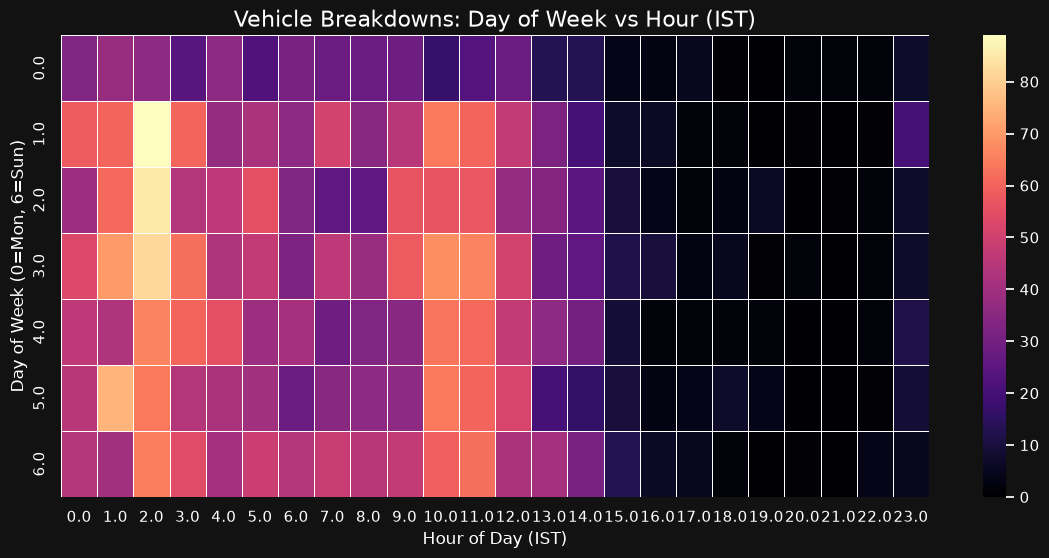

In [3]:
# Parse datetimes
df['start_datetime'] = pd.to_datetime(df['start_datetime'], errors='coerce')
df['resolved_datetime'] = pd.to_datetime(df['resolved_datetime'], errors='coerce')

# Convert UTC to IST
df['start_ist'] = df['start_datetime'] + pd.Timedelta(hours=5, minutes=30)
df['resolved_ist'] = df['resolved_datetime'] + pd.Timedelta(hours=5, minutes=30)

# Extract temporal features
df['hour'] = df['start_ist'].dt.hour
df['day_of_week'] = df['start_ist'].dt.dayofweek

# Calculate true duration in minutes
df['duration_mins'] = (df['resolved_ist'] - df['start_ist']).dt.total_seconds() / 60.0

# Plot Heatmap of Hour vs Day for Vehicle Breakdowns
breakdowns = df[df['event_cause'] == 'vehicle_breakdown']
heatmap_data = breakdowns.pivot_table(index='day_of_week', columns='hour', values='id', aggfunc='count', fill_value=0)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='magma', linewidths=.5)
plt.title('Vehicle Breakdowns: Day of Week vs Hour (IST)', fontsize=16, color='white')
plt.xlabel('Hour of Day (IST)')
plt.ylabel('Day of Week (0=Mon, 6=Sun)')
plt.show()

## 3. Spatial Topology & Corridor Bottlenecks

Identifying which specific corridors and police jurisdictions suffer the most extreme event durations.

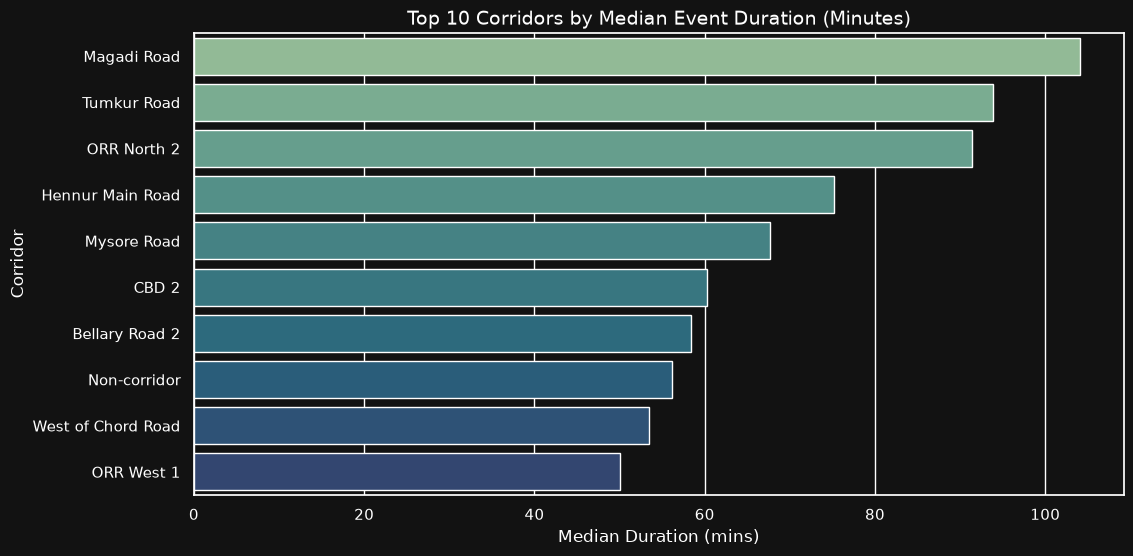

In [4]:
# Top 10 corridors by median duration
top_corridors = df.groupby('corridor')['duration_mins'].median().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_corridors.values, y=top_corridors.index, palette='crest')
plt.title('Top 10 Corridors by Median Event Duration (Minutes)', fontsize=14)
plt.xlabel('Median Duration (mins)')
plt.ylabel('Corridor')
plt.show()

## 4. Feature Engineering: Severity Index & Imputation Strategy

Creating a synthetic target variable to capture the true impact of an event, combining priority, road closure status, and duration.

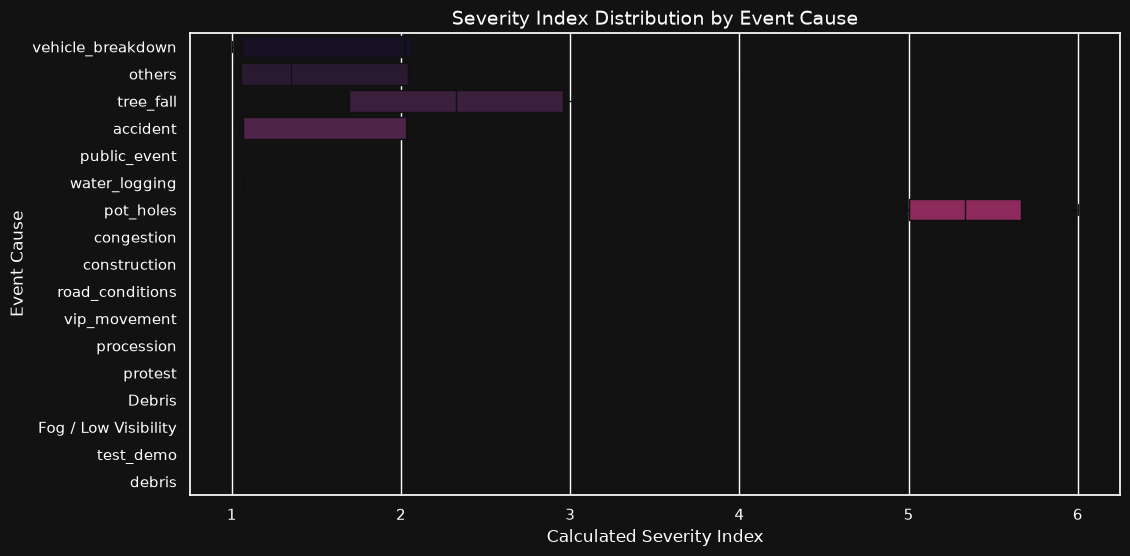

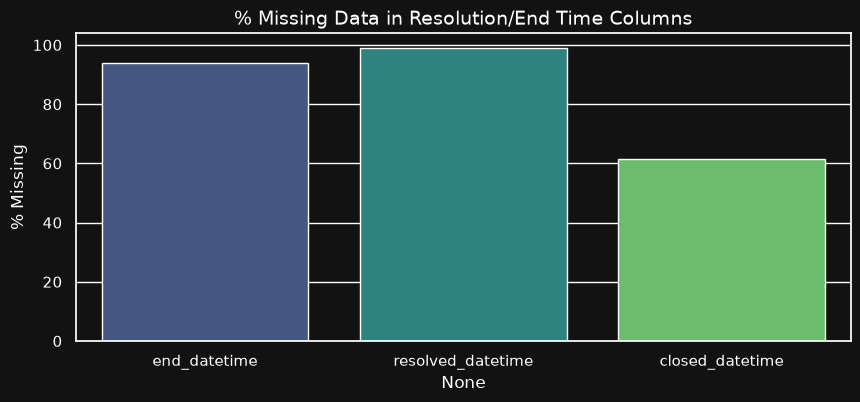

In [5]:
# Create Severity Index
df['priority_score'] = df['priority'].map({'High': 2, 'Low': 1}).fillna(1)
df['closure_score'] = df['requires_road_closure'].map({True: 2, False: 1, 'TRUE': 2, 'FALSE': 1}).fillna(1)

# Cap duration at 99th percentile to avoid outliers dominating the score
p99_dur = df['duration_mins'].quantile(0.99)
df['duration_capped'] = df['duration_mins'].clip(upper=p99_dur)
df['duration_score'] = df['duration_capped'] / df['duration_capped'].max() * 5 # Scale 0 to 5

df['severity_index'] = df['priority_score'] * df['closure_score'] + df['duration_score']

# Plot distribution of Severity Index by Event Cause
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='severity_index', y='event_cause', palette='rocket')
plt.title('Severity Index Distribution by Event Cause', fontsize=14)
plt.xlabel('Calculated Severity Index')
plt.ylabel('Event Cause')
plt.show()

# Visualize missing data pattern for our target engineering
missing_data = df[['end_datetime', 'resolved_datetime', 'closed_datetime']].isnull().sum() / len(df) * 100
plt.figure(figsize=(10, 4))
sns.barplot(x=missing_data.index, y=missing_data.values, palette='viridis')
plt.title('% Missing Data in Resolution/End Time Columns', fontsize=14)
plt.ylabel('% Missing')
plt.show()